# Taller 7: Predicción Climática con Redes LSTM, GRU y Random Forest

Este notebook refactoriza y extiende el enfoque de los cuadernos de ejemplo ubicados en `Material/`, especialmente el patrón didáctico del cuaderno `TIA_20260505_DL-2_RNN.ipynb`: uso de `Sequential`, construcción de secuencias, definición de capas recurrentes, `model.summary()` y cálculo manual de parámetros. La adaptación se realiza sobre el problema del **Jena Climate Dataset**, donde la entrada es una ventana temporal multivariada y la salida es la temperatura futura.

El objetivo experimental es comparar tres familias de modelos:

- **LSTM:** red recurrente con memoria explícita y mayor capacidad paramétrica.
- **GRU:** red recurrente más compacta, con dos compuertas explícitas y un candidato de estado.
- **Random Forest:** modelo tradicional de ensamble usado como línea base no secuencial.

### Cumplimiento: Parte 1 del Taller

Esta sección satisface el requerimiento de **preprocesamiento avanzado**. Se importa el Jena Climate Dataset, se realiza exploración inicial, se detectan valores atípicos con el criterio IQR, se manejan mediante recorte robusto (*clipping*) calculado únicamente con entrenamiento, se normalizan las variables y se construyen ventanas temporales configurables.

La estructura sigue la lógica del material base: primero se definen librerías e hiperparámetros, luego se prepara la serie temporal antes de alimentar las capas recurrentes. En lugar de una secuencia de caracteres como en los ejemplos de RNN/LSTM/GRU del material, aquí cada paso temporal contiene un vector meteorológico completo.

In [22]:
# Se importa Path para construir rutas portables dentro de la carpeta del taller.
from pathlib import Path

# Se importa random para fijar semillas reproducibles en operaciones de Python.
import random

# Se importa warnings para ocultar advertencias no críticas durante las gráficas o el entrenamiento.
import warnings

# Se importa NumPy para operaciones numéricas, arreglos y transformaciones tensoriales.
import numpy as np

# Se importa pandas para carga, limpieza, exploración y división temporal de datos tabulares.
import pandas as pd

# Se importa Matplotlib para construir gráficas de series, pérdidas y predicciones.
import matplotlib.pyplot as plt

# Se importa Seaborn para mejorar el estilo de tablas visuales, histogramas y mapas de calor.
import seaborn as sns

# Se importa TensorFlow como backend principal de Deep Learning.
import tensorflow as tf

# Se importa Keras desde TensorFlow, siguiendo el estilo del material base.
from tensorflow import keras

# Se importan capas de Keras para construir modelos secuenciales LSTM y GRU.
from tensorflow.keras import layers

# Se importa plot_model para generar los grafos visuales de arquitectura solicitados.
from tensorflow.keras.utils import plot_model

# Se importa display/Image para mostrar tablas estilizadas e imágenes dentro de Jupyter.
from IPython.display import display, Image

# Se importa RandomForestRegressor como línea base tradicional de ensamble.
from sklearn.ensemble import RandomForestRegressor

# Se importan métricas homogéneas de regresión para comparar todos los modelos.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Se silencian advertencias para mantener el notebook legible durante la ejecución.
warnings.filterwarnings("ignore")

# Se fija un estilo visual consistente para todo el análisis exploratorio y las curvas.
sns.set_theme(style="whitegrid", context="notebook")

# Se define el tamaño por defecto de las figuras para que sean legibles en Jupyter.
plt.rcParams["figure.figsize"] = (12, 5)

# Se fija una semilla para Python.
SEED = 42

# Se aplica la semilla a random.
random.seed(SEED)

# Se aplica la semilla a NumPy.
np.random.seed(SEED)

# Se aplica la semilla a TensorFlow.
tf.random.set_seed(SEED)

# Se define la carpeta base como la ubicación actual del notebook.
BASE_DIR = Path.cwd()

# Se define una carpeta local para datos descargados y artefactos generados.
DATA_DIR = BASE_DIR / "data"

# Se crea la carpeta de datos si aún no existe.
DATA_DIR.mkdir(exist_ok=True)

# Se define una carpeta para guardar grafos de modelos generados con plot_model.
ARTIFACTS_DIR = BASE_DIR / "artifacts"

# Se crea la carpeta de artefactos si aún no existe.
ARTIFACTS_DIR.mkdir(exist_ok=True)

# Se define la URL oficial del dataset usada comúnmente en los ejemplos de Keras.
JENA_URL = "https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip"

# Se define el muestreo: 6 registros de 10 minutos equivalen a una observación horaria.
SAMPLING_RATE = 6

# Se define k: número de pasos pasados incluidos en cada ventana.
LOOKBACK = 120

# Se define Delta: horizonte de predicción de 24 horas hacia adelante.
FORECAST_HORIZON = 24

# Se define el tamaño de lote para entrenar redes recurrentes con estabilidad y eficiencia.
BATCH_SIZE = 256

# Se define el máximo de épocas; EarlyStopping detendrá antes si validación no mejora.
MAX_EPOCHS = 20

# Se define paciencia de EarlyStopping para controlar sobreentrenamiento.
PATIENCE = 4

# Se define la variable objetivo que se desea predecir.
TARGET_COL = "T (degC)"

# Se imprime versión de TensorFlow para trazabilidad del experimento.
print("TensorFlow:", tf.__version__)

# Se imprime el directorio activo para confirmar que las rutas relativas apuntan al taller.
print("Directorio de trabajo:", BASE_DIR)

TensorFlow: 2.21.0
Directorio de trabajo: C:\Users\aiize\IA


### Cumplimiento: Parte 1 del Taller

Aquí se adapta la carga de datos al flujo usado en el material: se prepara primero el insumo, se inspeccionan dimensiones y se deja la serie lista para convertirla en secuencias. Si el CSV ya existe dentro de la carpeta del taller, se usa localmente; si no existe, se descarga desde el repositorio oficial usado por Keras.

In [23]:
# Se define una función para buscar el CSV localmente antes de descargarlo.
def buscar_csv_jena(raiz):
    # Se buscan archivos con el nombre oficial del Jena Climate Dataset.
    coincidencias = list(Path(raiz).rglob("jena_climate_2009_2016.csv"))
    # Se retorna la primera coincidencia si existe; de lo contrario se retorna None.
    return coincidencias[0] if coincidencias else None


# Se define una función de carga robusta del dataset.
def cargar_jena():
    # Se intenta localizar primero el CSV dentro de la carpeta del taller.
    ruta_csv = buscar_csv_jena(BASE_DIR)

    # Se verifica si no hay archivo local disponible.
    if ruta_csv is None:
        # Se informa al usuario que se descargará el dataset.
        print("CSV local no encontrado; descargando Jena Climate Dataset...")

        # Se descarga y extrae el ZIP oficial mediante la utilidad de Keras.
        keras.utils.get_file(
            fname="jena_climate_2009_2016.csv.zip",
            origin=JENA_URL,
            cache_dir=str(DATA_DIR),
            extract=True,
        )

        # Se vuelve a buscar el CSV después de extraer el archivo comprimido.
        ruta_csv = buscar_csv_jena(DATA_DIR)

    # Se valida que el CSV exista después de buscar o descargar.
    if ruta_csv is None:
        # Se lanza un error explícito si no fue posible cargar los datos.
        raise FileNotFoundError("No se encontró jena_climate_2009_2016.csv.")

    # Se muestra la ruta usada para trazabilidad del experimento.
    print("Dataset cargado desde:", ruta_csv)

    # Se lee el CSV con pandas.
    datos = pd.read_csv(ruta_csv)

    # Se convierte la columna temporal al tipo datetime con el formato original del dataset.
    datos["Date Time"] = pd.to_datetime(datos["Date Time"], format="%d.%m.%Y %H:%M:%S")

    # Se usa la fecha como índice para conservar explícitamente el orden temporal.
    datos = datos.set_index("Date Time")

    # Se ordena el índice por seguridad ante cualquier desorden en la fuente.
    datos = datos.sort_index()

    # Se retorna el DataFrame listo para exploración y preprocesamiento.
    return datos


# Se carga el dataset completo en frecuencia original de 10 minutos.
df_raw = cargar_jena()

# Se imprime la forma del dataset original.
print("Dimensiones originales:", df_raw.shape)

# Se muestran las primeras filas para verificar columnas, unidades y formato temporal.
display(df_raw.head())

# Se muestran las últimas filas para confirmar continuidad temporal hasta el final.
display(df_raw.tail())

Dataset cargado desde: C:\Users\aiize\IA\data\datasets\jena_climate_2009_2016_extracted\jena_climate_2009_2016.csv
Dimensiones originales: (420451, 14)


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2009-01-01 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
2009-01-01 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2009-01-01 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
2009-01-01 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
2009-01-01 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2016-12-31 23:20:00,1000.07,-4.05,269.10,-8.13,73.10,4.52,3.30,1.22,2.06,3.30,1292.98,0.67,1.52,240.0
2016-12-31 23:30:00,999.93,-3.35,269.81,-8.06,69.71,4.77,3.32,1.44,2.07,3.32,1289.44,1.14,1.92,234.3
2016-12-31 23:40:00,999.82,-3.16,270.01,-8.21,67.91,4.84,3.28,1.55,2.05,3.28,1288.39,1.08,2.00,215.2
2016-12-31 23:50:00,999.81,-4.23,268.94,-8.53,71.80,4.46,3.20,1.26,1.99,3.20,1293.56,1.49,2.16,225.8
2017-01-01 00:00:00,999.82,-4.82,268.36,-8.42,75.70,4.27,3.23,1.04,2.01,3.23,1296.38,1.23,1.96,184.9


#### Discusión técnica del resultado de carga

La tabla inicial confirma que el dataset contiene variables meteorológicas continuas, por ejemplo temperatura, presión, humedad, densidad de vapor y viento. El índice temporal permite hacer divisiones cronológicas, condición necesaria para evitar fuga de información en series temporales. A diferencia de una tarea de clasificación estática, aquí no se puede barajar todo el dataset antes de separar train/validation/test, porque eso permitiría entrenar con observaciones posteriores al periodo de prueba.

### Cumplimiento: Parte 1 del Taller

El análisis exploratorio satisface el requerimiento de estudiar variables como temperatura, presión y humedad. Se revisan estadísticos, valores faltantes, distribuciones y correlaciones para entender escala, ruido y relaciones físicas antes de construir las ventanas recurrentes.

In [24]:
# Se calcula una tabla descriptiva con media, desviación, mínimos, máximos y cuartiles.
tabla_descriptiva = df_raw.describe().T

# Se agrega el conteo de valores faltantes por variable.
tabla_descriptiva["faltantes"] = df_raw.isna().sum()

# Se agrega el porcentaje de faltantes por variable.
tabla_descriptiva["faltantes_%"] = 100 * tabla_descriptiva["faltantes"] / len(df_raw)

# Se muestra la tabla para evaluar escala, dispersión y calidad de datos.
display(tabla_descriptiva)

,count,mean,std,min,25%,50%,75%,max,faltantes,faltantes_%
p (mbar),420451.0,989.212508,8.359454,913.60,984.20,989.57,994.72,1015.35,0,0.0
T (degC),420451.0,9.448567,8.423685,-23.01,3.36,9.41,15.47,37.28,0,0.0
Tpot (K),420451.0,283.491182,8.504820,250.60,277.43,283.46,289.53,311.34,0,0.0
Tdew (degC),420451.0,4.954011,6.730411,-25.01,0.24,5.21,10.07,23.11,0,0.0
rh (%),420451.0,76.007045,16.477126,12.95,65.21,79.30,89.40,100.00,0,0.0
VPmax (mbar),420451.0,13.575089,7.739481,0.95,7.78,11.82,17.60,63.77,0,0.0
VPact (mbar),420451.0,9.532524,4.183895,0.79,6.21,8.86,12.35,28.32,0,0.0
VPdef (mbar),420451.0,4.042483,4.897270,0.00,0.87,2.19,5.30,46.01,0,0.0
sh (g/kg),420451.0,6.021630,2.655973,0.50,3.92,5.59,7.80,18.13,0,0.0
H2OC (mmol/mol),420451.0,9.638982,4.235130,0.80,6.29,8.96,12.48,28.82,0,0.0


#### Discusión técnica de la tabla descriptiva

La tabla evidencia que las variables están en escalas diferentes: presión se mide alrededor de cientos de mbar, humedad en porcentaje y temperatura en grados Celsius. Esta heterogeneidad exige normalización antes de entrenar LSTM/GRU, porque las redes optimizadas por gradiente son sensibles a magnitudes desbalanceadas. La columna de faltantes permite decidir si se requiere imputación; si el porcentaje es cero, se puede continuar sin interpolación adicional.

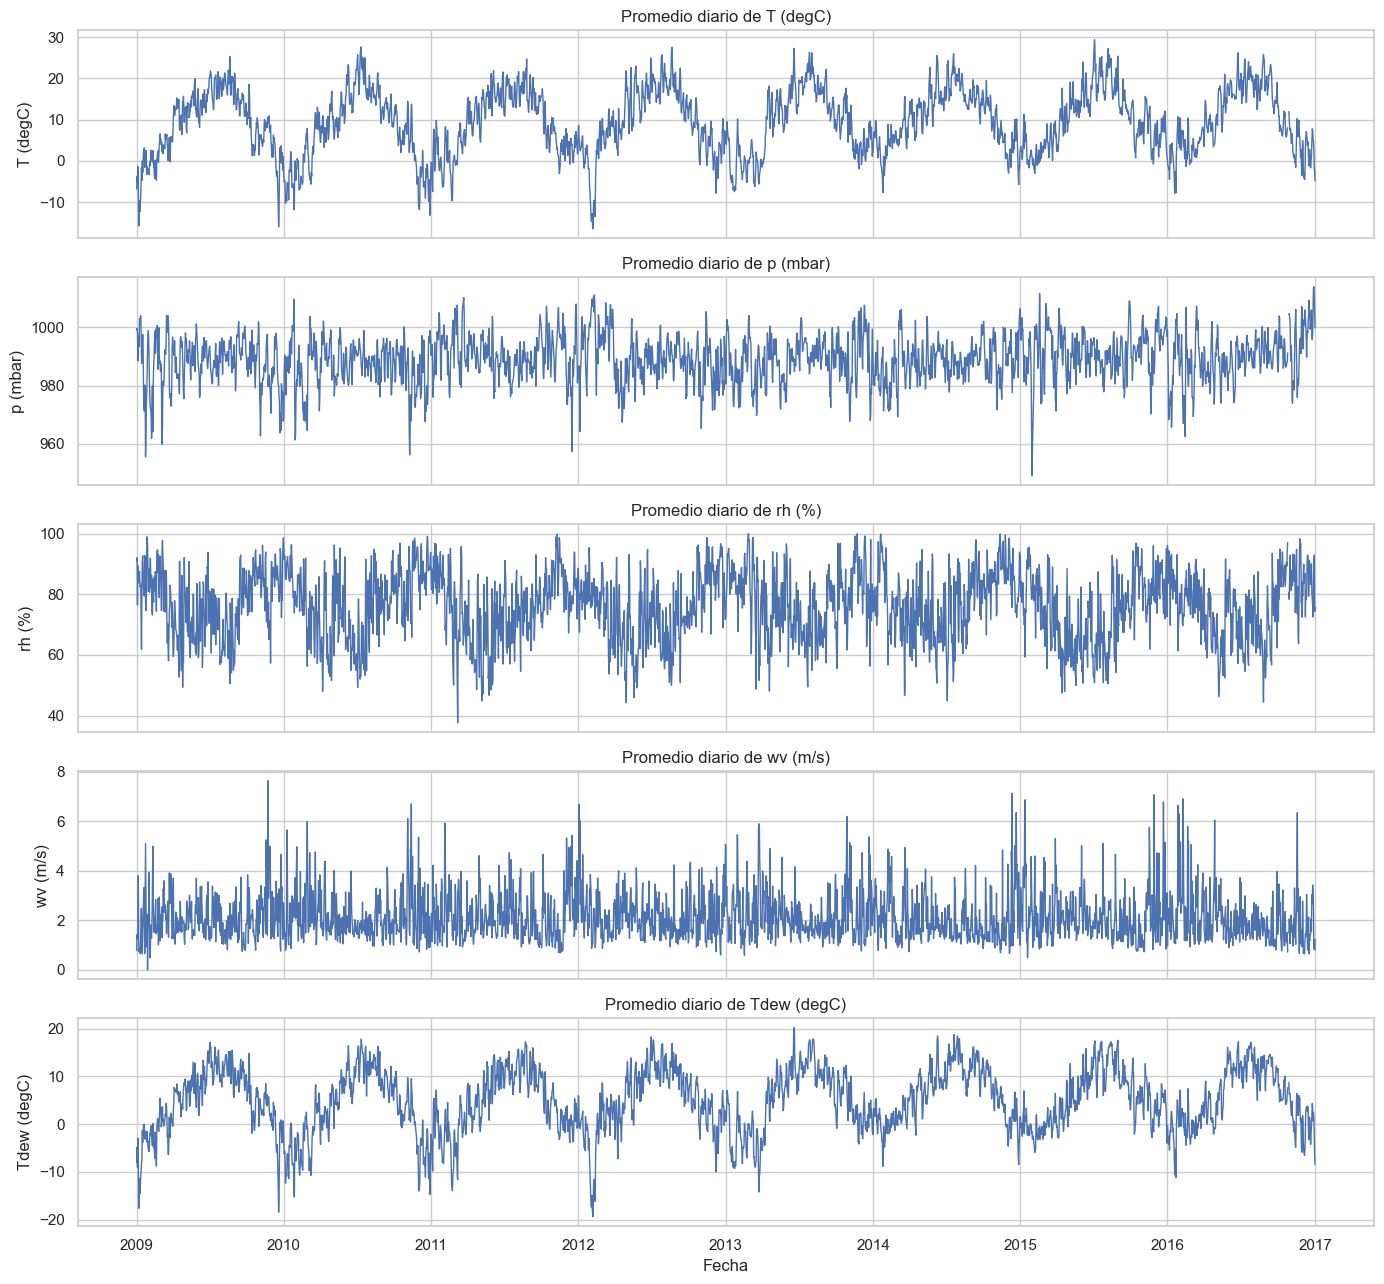

In [25]:
# Se seleccionan variables meteorológicas representativas para graficar.
variables_clave = ["T (degC)", "p (mbar)", "rh (%)", "wv (m/s)", "Tdew (degC)"]

# Se filtran las variables clave para evitar errores si alguna columna no existe en otra versión del archivo.
variables_clave = [col for col in variables_clave if col in df_raw.columns]

# Se remuestrea a promedio diario solo para visualizar tendencias sin saturar la gráfica.
df_diario = df_raw[variables_clave].resample("D").mean()

# Se crea una figura con una fila por variable.
fig, axes = plt.subplots(len(variables_clave), 1, figsize=(14, 2.6 * len(variables_clave)), sharex=True)

# Se garantiza que axes sea iterable incluso si solo hay una variable.
axes = np.atleast_1d(axes)

# Se recorre cada variable para dibujar su evolución temporal.
for ax, columna in zip(axes, variables_clave):
    # Se grafica el promedio diario de la variable actual.
    ax.plot(df_diario.index, df_diario[columna], linewidth=1.0)

    # Se asigna un título descriptivo por variable.
    ax.set_title(f"Promedio diario de {columna}")

    # Se etiqueta el eje vertical con el nombre y unidad de la variable.
    ax.set_ylabel(columna)

# Se etiqueta el eje horizontal compartido.
plt.xlabel("Fecha")

# Se ajusta el diseño para evitar superposición.
plt.tight_layout()

# Se muestra la figura en el notebook.
plt.show()

#### Discusión técnica de las series temporales

Las curvas diarias permiten observar estacionalidad anual, ciclos de temperatura y cambios de presión/humedad. La temperatura y el punto de rocío suelen moverse de forma relacionada, mientras que humedad relativa puede reaccionar de manera inversa a la temperatura durante ciertos periodos. Estos patrones justifican el uso de redes recurrentes: el valor futuro no depende solo del instante actual, sino de la evolución de varios días.

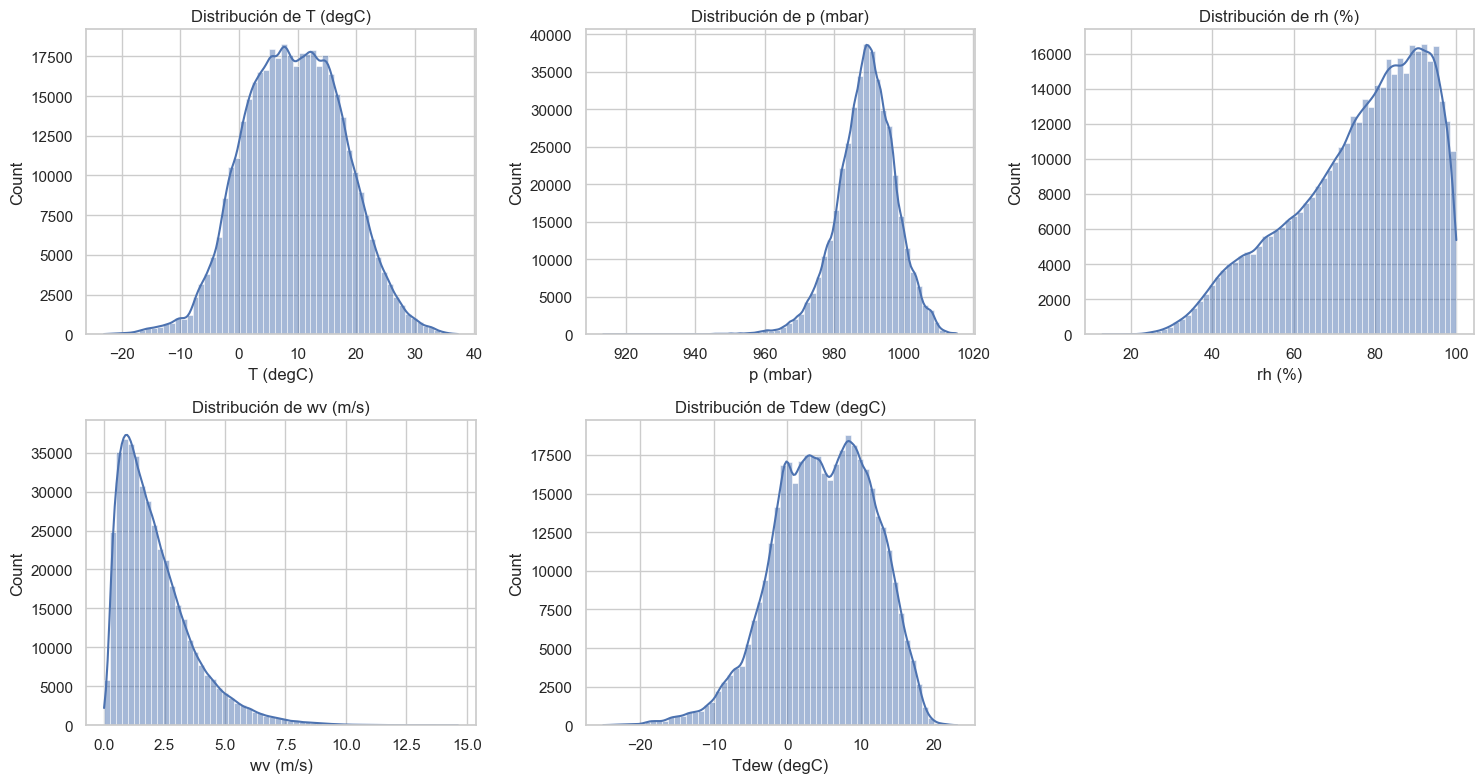

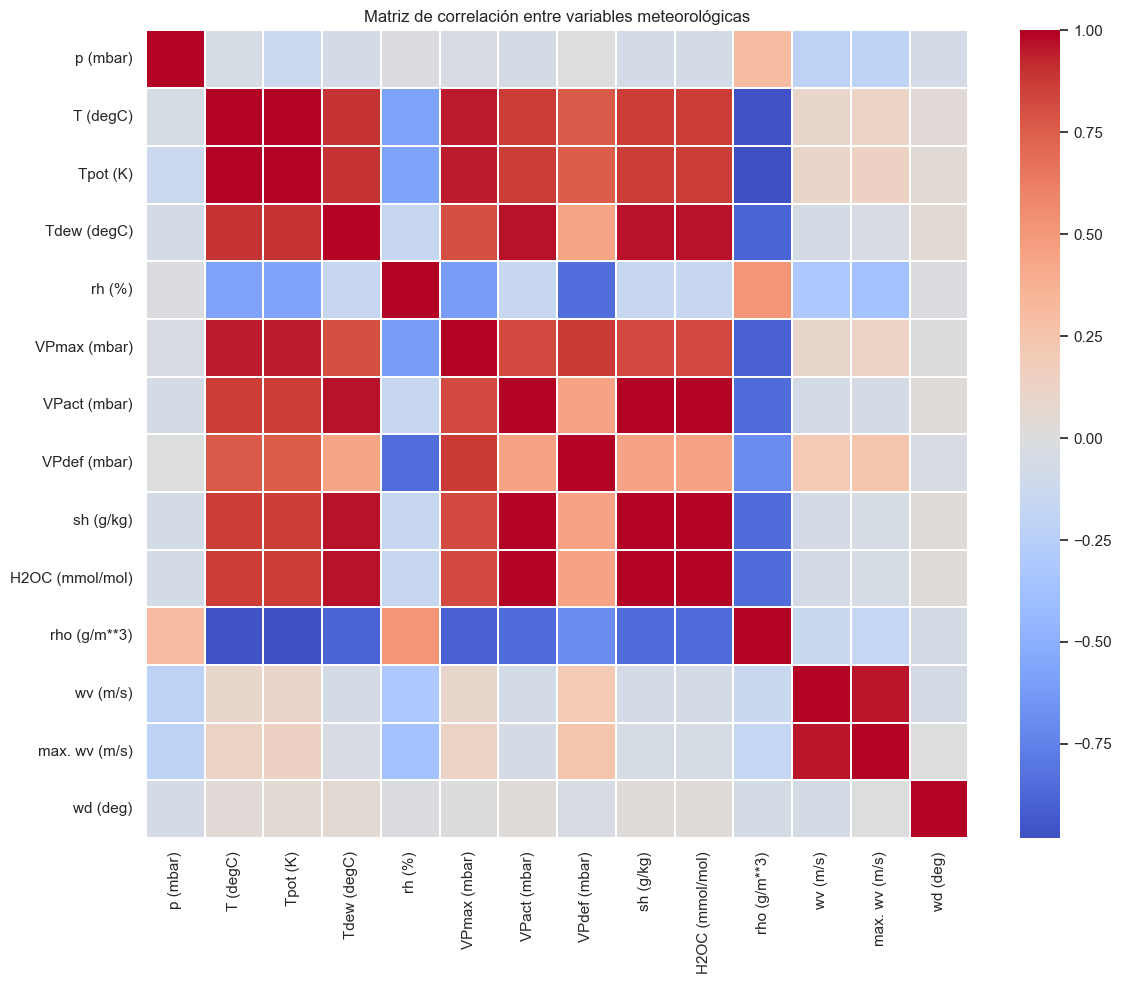

In [26]:
# Se crea una figura para histogramas de variables clave.
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Se aplana la matriz de ejes para iterar con facilidad.
axes = axes.flatten()

# Se recorre cada variable clave disponible.
for ax, columna in zip(axes, variables_clave):
    # Se dibuja histograma con curva KDE para observar forma y dispersión.
    sns.histplot(df_raw[columna], bins=60, kde=True, ax=ax)

    # Se asigna un título para identificar la variable.
    ax.set_title(f"Distribución de {columna}")

# Se eliminan ejes vacíos si hay menos de seis variables.
for ax in axes[len(variables_clave):]:
    # Se remueve el eje no usado de la figura.
    ax.remove()

# Se ajustan espacios de la figura.
plt.tight_layout()

# Se muestran las distribuciones.
plt.show()

# Se calcula matriz de correlación usando columnas numéricas.
matriz_correlacion = df_raw.corr(numeric_only=True)

# Se crea una figura grande para el mapa de calor.
plt.figure(figsize=(12, 10))

# Se dibuja el mapa de calor centrado en cero para distinguir correlaciones positivas y negativas.
sns.heatmap(matriz_correlacion, cmap="coolwarm", center=0, linewidths=0.3)

# Se asigna título a la matriz de correlación.
plt.title("Matriz de correlación entre variables meteorológicas")

# Se ajusta el diseño.
plt.tight_layout()

# Se muestra la figura.
plt.show()

#### Discusión técnica de distribuciones y correlaciones

Las distribuciones revelan si hay asimetrías o valores extremos. En clima, el viento suele ser más ruidoso y sesgado que temperatura o presión. La correlación orienta qué variables podrían aportar señal predictiva: punto de rocío, humedad y temperatura están físicamente acopladas. Sin embargo, una correlación global no sustituye el modelado temporal, porque un rezago específico puede ser informativo aunque la correlación agregada sea moderada.

### Cumplimiento: Parte 1 del Taller

Esta celda implementa explícitamente la detección y manejo de atípicos. El criterio IQR se calcula solo con entrenamiento, de forma similar a como se calculan estadísticas de normalización solo con datos disponibles en el pasado. El tratamiento elegido es *clipping*: no elimina registros ni rompe la continuidad temporal, sino que limita valores extremos a umbrales robustos.

In [27]:
# Se reduce la frecuencia original a una observación por hora para hacer viable el entrenamiento.
df_horario = df_raw.iloc[::SAMPLING_RATE].copy()

# Se calcula la cantidad total de observaciones horarias.
n_total = len(df_horario)

# Se define el final del bloque de entrenamiento como el 70% inicial.
fin_train = int(n_total * 0.70)

# Se define el final del bloque de validación como el 85% inicial.
fin_val = int(n_total * 0.85)

# Se separa entrenamiento respetando el orden cronológico.
df_train = df_horario.iloc[:fin_train].copy()

# Se separa validación respetando el orden cronológico.
df_val = df_horario.iloc[fin_train:fin_val].copy()

# Se separa prueba con el tramo final de la serie.
df_test = df_horario.iloc[fin_val:].copy()

# Se calcula Q1 por variable usando solo entrenamiento.
q1 = df_train.quantile(0.25)

# Se calcula Q3 por variable usando solo entrenamiento.
q3 = df_train.quantile(0.75)

# Se calcula el rango intercuartílico por variable.
iqr = q3 - q1

# Se define el límite inferior robusto para detectar atípicos.
limite_inferior = q1 - 1.5 * iqr

# Se define el límite superior robusto para detectar atípicos.
limite_superior = q3 + 1.5 * iqr

# Se identifica si cada valor del dataset horario cae fuera de los límites IQR.
mascara_atipicos = (df_horario < limite_inferior) | (df_horario > limite_superior)

# Se resume la cantidad de atípicos por variable.
tabla_atipicos = pd.DataFrame({
    "atipicos": mascara_atipicos.sum(),
    "atipicos_%": 100 * mascara_atipicos.sum() / len(df_horario),
    "limite_inferior_train": limite_inferior,
    "limite_superior_train": limite_superior,
})

# Se muestran los atípicos ordenados de mayor a menor porcentaje.
display(tabla_atipicos.sort_values("atipicos_%", ascending=False))

# Se aplica clipping a entrenamiento con límites calculados desde entrenamiento.
df_train_limpio = df_train.clip(lower=limite_inferior, upper=limite_superior, axis=1)

# Se aplica el mismo clipping a validación para evitar usar información futura.
df_val_limpio = df_val.clip(lower=limite_inferior, upper=limite_superior, axis=1)

# Se aplica el mismo clipping a prueba para mantener evaluación comparable.
df_test_limpio = df_test.clip(lower=limite_inferior, upper=limite_superior, axis=1)

,atipicos,atipicos_%,limite_inferior_train,limite_superior_train
VPdef (mbar),5339,7.618871,-5.860,11.980
wv (m/s),2315,3.303556,-1.800,5.720
VPmax (mbar),1955,2.789828,-7.235,32.245
max. wv (m/s),1855,2.647126,-2.700,9.300
p (mbar),1103,1.574005,967.905,1009.785
rho (g/m**3),490,0.699241,1104.550,1326.710
Tdew (degC),376,0.536560,-14.910,24.690
sh (g/kg),296,0.422399,-1.920,13.440
H2OC (mmol/mol),285,0.406701,-3.060,21.500
VPact (mbar),273,0.389577,-3.040,21.280


#### Discusión técnica de atípicos

El conteo de atípicos indica qué variables son más sensibles a eventos extremos o ruido instrumental. El viento suele presentar más valores extremos por ráfagas, mientras que presión y temperatura tienden a ser más estables. El *clipping* es preferible a eliminar filas porque las redes recurrentes necesitan continuidad temporal para formar ventanas. Además, los límites se calculan únicamente en entrenamiento para evitar que validación o prueba influyan en las transformaciones.

### Cumplimiento: Parte 1 del Taller

Se normalizan variables y se construyen ventanas configurables \(X=[x_{t-k},...,x_t]\) para predecir \(x_{t+\Delta}\). La ventana `LOOKBACK=120` representa cinco días de historia horaria, suficiente para capturar varios ciclos diarios. El horizonte `FORECAST_HORIZON=24` define una predicción de temperatura un día hacia adelante.

In [28]:
# Se calculan medias únicamente con el bloque de entrenamiento limpio.
media_train = df_train_limpio.mean()

# Se calculan desviaciones estándar únicamente con el bloque de entrenamiento limpio.
std_train = df_train_limpio.std()

# Se reemplazan desviaciones cero por uno para evitar divisiones inválidas.
std_train = std_train.replace(0, 1.0)

# Se normaliza entrenamiento con estadísticas de entrenamiento.
train_norm = (df_train_limpio - media_train) / std_train

# Se normaliza validación con las mismas estadísticas de entrenamiento.
val_norm = (df_val_limpio - media_train) / std_train

# Se normaliza prueba con las mismas estadísticas de entrenamiento.
test_norm = (df_test_limpio - media_train) / std_train

# Se define la lista de columnas usadas como variables de entrada.
feature_cols = train_norm.columns.tolist()

# Se localiza la posición de la temperatura dentro de las variables de entrada.
target_index = feature_cols.index(TARGET_COL)

# Se muestra un resumen para verificar que entrenamiento quedó centrado y escalado.
display(train_norm.describe().T[["mean", "std", "min", "max"]])

,mean,std,min,max
p (mbar),1.455473e-15,1.0,-2.576011,2.606700
T (degC),1.761401e-16,1.0,-2.852697,2.863827
Tpot (K),-1.390580e-17,1.0,-2.817080,2.834837
Tdew (degC),-2.781159e-17,1.0,-2.826276,2.676994
rh (%),2.549396e-16,1.0,-2.866077,1.456363
VPmax (mbar),-1.251522e-16,1.0,-1.698998,2.639380
VPact (mbar),3.893623e-16,1.0,-2.043978,2.849936
VPdef (mbar),-8.111715e-17,1.0,-0.993901,2.298830
sh (g/kg),-1.483285e-16,1.0,-2.035616,2.835777
H2OC (mmol/mol),1.715048e-16,1.0,-2.042909,2.842095


#### Discusión técnica de la normalización

El entrenamiento queda aproximadamente con media cero y desviación estándar uno. Esta transformación facilita la optimización con Adam, porque evita que variables de gran escala dominen los gradientes. La normalización de validación y prueba con estadísticas de entrenamiento reproduce el escenario real: al predecir futuro, no se conocen sus estadísticas globales.

In [29]:
# Se define una función configurable para crear ventanas temporales supervisadas.
def crear_ventanas(df_normalizado, columnas, objetivo, lookback, horizonte):
    # Se convierte el DataFrame normalizado a matriz NumPy de tipo float32 para Keras.
    valores = df_normalizado[columnas].to_numpy(dtype=np.float32)

    # Se extrae la serie objetivo normalizada como vector float32.
    objetivo_valores = df_normalizado[objetivo].to_numpy(dtype=np.float32)

    # Se conserva el índice temporal para asociar cada y con su fecha real.
    indice_temporal = df_normalizado.index

    # Se calcula cuántas ventanas completas caben en el segmento.
    n_muestras = len(df_normalizado) - lookback - horizonte + 1

    # Se valida que el segmento sea suficientemente largo para k y Delta.
    if n_muestras <= 0:
        # Se lanza un error explicativo si no hay ventanas posibles.
        raise ValueError("El segmento es demasiado corto para lookback y horizonte.")

    # Se reserva memoria para el tensor 3D: muestras, pasos temporales y variables.
    X = np.empty((n_muestras, lookback, len(columnas)), dtype=np.float32)

    # Se reserva memoria para el vector objetivo.
    y = np.empty((n_muestras,), dtype=np.float32)

    # Se crea una lista para guardar la fecha de cada objetivo.
    fechas_y = []

    # Se recorre cada posible posición inicial de ventana.
    for inicio in range(n_muestras):
        # Se calcula el final exclusivo de la ventana de entrada.
        fin = inicio + lookback

        # Se calcula la posición del objetivo futuro t + Delta.
        pos_objetivo = fin + horizonte - 1

        # Se asigna la secuencia multivariada X=[x_{t-k},...,x_t].
        X[inicio] = valores[inicio:fin]

        # Se asigna la temperatura futura como objetivo.
        y[inicio] = objetivo_valores[pos_objetivo]

        # Se guarda la fecha exacta del objetivo para visualizaciones posteriores.
        fechas_y.append(indice_temporal[pos_objetivo])

    # Se retorna X, y y las fechas del objetivo.
    return X, y, pd.DatetimeIndex(fechas_y)


# Se crean ventanas de entrenamiento.
X_train, y_train, fechas_train = crear_ventanas(train_norm, feature_cols, TARGET_COL, LOOKBACK, FORECAST_HORIZON)

# Se crean ventanas de validación.
X_val, y_val, fechas_val = crear_ventanas(val_norm, feature_cols, TARGET_COL, LOOKBACK, FORECAST_HORIZON)

# Se crean ventanas de prueba.
X_test, y_test, fechas_test = crear_ventanas(test_norm, feature_cols, TARGET_COL, LOOKBACK, FORECAST_HORIZON)

# Se imprime la forma de entrenamiento para verificar compatibilidad con Keras.
print("X_train:", X_train.shape, "y_train:", y_train.shape)

# Se imprime la forma de validación para verificar consistencia.
print("X_val:", X_val.shape, "y_val:", y_val.shape)

# Se imprime la forma de prueba para verificar consistencia.
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train: (48910, 120, 14) y_train: (48910,)
X_val: (10368, 120, 14) y_val: (10368,)
X_test: (10369, 120, 14) y_test: (10369,)


#### Discusión técnica de ventanas

Cada muestra tiene forma `(120, número_de_variables)`, es decir, cinco días horarios de contexto meteorológico. Esta representación conserva el orden temporal dentro de cada ventana y permite que LSTM/GRU aprendan dependencias entre rezagos. Aumentar `LOOKBACK` puede mejorar la captura de estacionalidad semanal o frentes lentos, pero incrementa memoria, tiempo de entrenamiento y riesgo de sobreajuste. Reducirlo acelera el experimento, aunque puede perder ciclos relevantes.

In [30]:
# Se define una función para construir datasets eficientes de TensorFlow.
def crear_dataset_tf(X, y, barajar=False):
    # Se crea un Dataset desde tensores NumPy.
    dataset = tf.data.Dataset.from_tensor_slices((X, y))

    # Se barajan solo las ventanas de entrenamiento si se solicita.
    if barajar:
        # Se usa una semilla fija para reproducibilidad.
        dataset = dataset.shuffle(buffer_size=len(X), seed=SEED, reshuffle_each_iteration=True)

    # Se agrupan muestras en lotes para entrenamiento vectorizado.
    dataset = dataset.batch(BATCH_SIZE)

    # Se activa prefetch para solapar preparación de datos y entrenamiento.
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    # Se retorna el pipeline listo para Keras.
    return dataset


# Se construye dataset de entrenamiento con barajado de ventanas.
train_ds = crear_dataset_tf(X_train, y_train, barajar=True)

# Se construye dataset de validación sin barajado.
val_ds = crear_dataset_tf(X_val, y_val, barajar=False)

# Se construye dataset de prueba sin barajado.
test_ds = crear_dataset_tf(X_test, y_test, barajar=False)

# Se obtiene el número de variables por paso temporal.
n_features = X_train.shape[-1]

# Se imprime el número de variables para usarlo en fórmulas de parámetros.
print("Número de variables de entrada:", n_features)

Número de variables de entrada: 14


#### Discusión técnica del pipeline

El barajado se aplica a ventanas completas, no a pasos individuales. Por tanto, no destruye el orden interno de cada secuencia. `prefetch` mejora el rendimiento porque prepara el siguiente lote mientras el modelo procesa el actual. Esta estructura mantiene el espíritu del material base: las secuencias se transforman a la forma requerida por la capa recurrente antes del entrenamiento.

### Cumplimiento: Partes 2 y 3 del Taller

Esta sección construye los modelos recurrentes solicitados partiendo del estilo del material: `Sequential`, capas recurrentes, `Dense` de salida y `model.summary()`. Se añaden capas `Dropout` para mitigar sobreajuste y se generan grafos visuales con `tensorflow.keras.utils.plot_model`.

In [31]:
# Se define una función para construir el modelo LSTM.
def construir_lstm(lookback, n_features):
    # Se crea un modelo secuencial como en los ejemplos del material base.
    modelo = keras.Sequential(name="modelo_lstm_jena")

    # Se declara explícitamente la forma de entrada: pasos temporales por variables.
    modelo.add(layers.Input(shape=(lookback, n_features), name="entrada_ventana"))

    # Se añade una primera LSTM con 64 unidades y salida secuencial para apilar otra recurrente.
    modelo.add(layers.LSTM(64, return_sequences=True, name="lstm_64"))

    # Se añade Dropout para apagar 20% de activaciones durante entrenamiento.
    modelo.add(layers.Dropout(0.20, name="dropout_lstm_1"))

    # Se añade una segunda LSTM de 32 unidades que resume la secuencia completa.
    modelo.add(layers.LSTM(32, name="lstm_32"))

    # Se añade un segundo Dropout para regularizar la representación temporal final.
    modelo.add(layers.Dropout(0.20, name="dropout_lstm_2"))

    # Se añade una capa densa intermedia con activación ReLU para combinación no lineal.
    modelo.add(layers.Dense(16, activation="relu", name="dense_relu"))

    # Se añade una neurona de salida para regresión de temperatura normalizada.
    modelo.add(layers.Dense(1, name="salida_temperatura"))

    # Se compila el modelo con Adam y MSE, coherente con regresión continua.
    modelo.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="mse", metrics=["mae"])

    # Se retorna el modelo compilado.
    return modelo


# Se instancia el modelo LSTM con la forma de las ventanas.
lstm_model = construir_lstm(LOOKBACK, n_features)

# Se imprime el resumen de capas y parámetros como en el material base.
lstm_model.summary()

Model: "modelo_lstm_jena"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_64 (LSTM)                       │ (None, 120, 64)             │          20,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_lstm_1 (Dropout)             │ (None, 120, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_32 (LSTM)                       │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_lstm_2 (Dropout)             │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_relu (Dense)                   │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ salida_temperatura (Dense)           │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 33,185 (129.63 KB)

 Trainable params: 33,185 (129.63 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# Se define la ruta de salida para el grafo visual de la LSTM.
ruta_lstm_plot = ARTIFACTS_DIR / "arquitectura_lstm.png"

# Se intenta generar el diagrama de arquitectura con plot_model.
try:
    # Se guarda el grafo mostrando formas de entrada/salida y nombres de capas.
    plot_model(lstm_model, to_file=str(ruta_lstm_plot), show_shapes=True, show_layer_names=True, dpi=120)

    # Se muestra la imagen generada dentro del notebook.
    display(Image(filename=str(ruta_lstm_plot)))

# Se captura cualquier error por ausencia de Graphviz/pydot en el entorno.
except Exception as error:
    # Se informa el problema sin detener el notebook.
    print("No fue posible generar el grafo LSTM con plot_model.")

    # Se muestra la causa técnica para que pueda instalarse graphviz/pydot si se requiere.
    print("Detalle:", error)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
No fue posible generar el grafo LSTM con plot_model.
Detalle: [Errno 2] No such file or directory: 'C:\\Users\\aiize\\IA\\artifacts\\arquitectura_lstm.png'


#### Discusión técnica del grafo LSTM

El grafo debe mostrar una entrada tridimensional `(batch, 120, variables)`, dos capas LSTM, dos Dropout y dos capas densas. La primera LSTM conserva la dimensión temporal mediante `return_sequences=True`, lo que permite que la segunda LSTM procese una secuencia de representaciones. La segunda LSTM condensa la información en un vector final usado para regresión.

In [33]:
# Se define una función para construir el modelo GRU.
def construir_gru(lookback, n_features):
    # Se crea un modelo secuencial siguiendo el patrón de construcción del material.
    modelo = keras.Sequential(name="modelo_gru_jena")

    # Se declara la forma de entrada esperada por la GRU.
    modelo.add(layers.Input(shape=(lookback, n_features), name="entrada_ventana"))

    # Se añade una primera GRU con 64 unidades y secuencia completa como salida.
    modelo.add(layers.GRU(64, return_sequences=True, reset_after=False, name="gru_64"))

    # Se añade Dropout para reducir sobreajuste en activaciones recurrentes.
    modelo.add(layers.Dropout(0.20, name="dropout_gru_1"))

    # Se añade una segunda GRU de 32 unidades que resume la secuencia.
    modelo.add(layers.GRU(32, reset_after=False, name="gru_32"))

    # Se añade Dropout adicional para regularizar la representación final.
    modelo.add(layers.Dropout(0.20, name="dropout_gru_2"))

    # Se añade una capa densa intermedia con activación ReLU.
    modelo.add(layers.Dense(16, activation="relu", name="dense_relu"))

    # Se añade la salida escalar para temperatura futura normalizada.
    modelo.add(layers.Dense(1, name="salida_temperatura"))

    # Se compila el modelo con la misma configuración que LSTM para comparación justa.
    modelo.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="mse", metrics=["mae"])

    # Se retorna el modelo compilado.
    return modelo


# Se instancia el modelo GRU con la forma de entrada definida por las ventanas.
gru_model = construir_gru(LOOKBACK, n_features)

# Se imprime el resumen del modelo GRU como en los ejemplos de GRU del material.
gru_model.summary()

Model: "modelo_gru_jena"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru_64 (GRU)                         │ (None, 120, 64)             │          15,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_gru_1 (Dropout)              │ (None, 120, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_32 (GRU)                         │ (None, 32)                  │           9,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_gru_2 (Dropout)              │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_relu (Dense)                   │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ salida_temperatura (Dense)           │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 25,025 (97.75 KB)

 Trainable params: 25,025 (97.75 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# Se define la ruta de salida para el grafo visual de la GRU.
ruta_gru_plot = ARTIFACTS_DIR / "arquitectura_gru.png"

# Se intenta generar el diagrama de arquitectura con plot_model.
try:
    # Se guarda el grafo mostrando formas y nombres de capas.
    plot_model(gru_model, to_file=str(ruta_gru_plot), show_shapes=True, show_layer_names=True, dpi=120)

    # Se muestra la imagen generada en el notebook.
    display(Image(filename=str(ruta_gru_plot)))

# Se captura cualquier error por ausencia de dependencias gráficas.
except Exception as error:
    # Se informa que el grafo no pudo generarse.
    print("No fue posible generar el grafo GRU con plot_model.")

    # Se imprime el detalle técnico del error.
    print("Detalle:", error)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
No fue posible generar el grafo GRU con plot_model.
Detalle: [Errno 2] No such file or directory: 'C:\\Users\\aiize\\IA\\artifacts\\arquitectura_gru.png'


#### Discusión técnica del grafo GRU

El grafo de la GRU es análogo al de la LSTM, pero sus capas recurrentes tienen menos parámetros. Se usa `reset_after=False` para que la parametrización coincida con la fórmula clásica del material: tres bloques de pesos por capa GRU. La GRU tiende a ser más eficiente porque usa dos compuertas explícitas, actualización y reinicio, más el candidato de estado; por eso reduce operaciones frente a la LSTM.

### Cumplimiento: Partes 2 y 3 del Taller

Se calcula manualmente la complejidad paramétrica de LSTM y GRU con las fórmulas solicitadas:

\[
P_{LSTM}=4(dh+h^2+h)
\]

\[
P_{GRU}=3(dh+h^2+h)
\]

En LSTM, el factor 4 representa entrada, olvido, salida y candidato de celda. En GRU, el factor 3 representa actualización, reinicio y candidato. Aunque la GRU tiene dos compuertas explícitas, la fórmula incluye el bloque candidato; por eso aparecen tres grupos de parámetros.

In [35]:
# Se define función para parámetros LSTM según la fórmula del taller.
def params_lstm(d, h):
    # Se retorna 4 veces pesos de entrada, pesos recurrentes y sesgo.
    return 4 * (d * h + h * h + h)


# Se define función para parámetros GRU según la fórmula del taller.
def params_gru(d, h):
    # Se retorna 3 veces pesos de entrada, pesos recurrentes y sesgo.
    return 3 * (d * h + h * h + h)


# Se define función para parámetros de una capa densa.
def params_dense(d, h):
    # Se retorna pesos más sesgos de la capa densa.
    return d * h + h


# Se construye una tabla con el desglose manual de LSTM.
tabla_parametros_lstm = pd.DataFrame([
    {"Modelo": "LSTM", "Capa": "LSTM 1", "d": n_features, "h": 64, "Parámetros": params_lstm(n_features, 64)},
    {"Modelo": "LSTM", "Capa": "LSTM 2", "d": 64, "h": 32, "Parámetros": params_lstm(64, 32)},
    {"Modelo": "LSTM", "Capa": "Dense ReLU", "d": 32, "h": 16, "Parámetros": params_dense(32, 16)},
    {"Modelo": "LSTM", "Capa": "Dense salida", "d": 16, "h": 1, "Parámetros": params_dense(16, 1)},
])

# Se construye una tabla con el desglose manual de GRU.
tabla_parametros_gru = pd.DataFrame([
    {"Modelo": "GRU", "Capa": "GRU 1", "d": n_features, "h": 64, "Parámetros": params_gru(n_features, 64)},
    {"Modelo": "GRU", "Capa": "GRU 2", "d": 64, "h": 32, "Parámetros": params_gru(64, 32)},
    {"Modelo": "GRU", "Capa": "Dense ReLU", "d": 32, "h": 16, "Parámetros": params_dense(32, 16)},
    {"Modelo": "GRU", "Capa": "Dense salida", "d": 16, "h": 1, "Parámetros": params_dense(16, 1)},
])

# Se concatena el desglose de ambos modelos.
tabla_parametros = pd.concat([tabla_parametros_lstm, tabla_parametros_gru], ignore_index=True)

# Se calcula el total manual por modelo.
tabla_totales = tabla_parametros.groupby("Modelo", as_index=False)["Parámetros"].sum()

# Se agrega el conteo reportado por Keras para verificación.
tabla_totales["Parámetros Keras"] = [gru_model.count_params(), lstm_model.count_params()]

# Se ordena la tabla por modelo para lectura estable.
tabla_totales = tabla_totales.sort_values("Modelo")

# Se muestran los parámetros por capa.
display(tabla_parametros)

# Se muestran los totales manuales y los totales reportados por Keras.
display(tabla_totales)

,Modelo,Capa,d,h,Parámetros
0,LSTM,LSTM 1,14,64,20224
1,LSTM,LSTM 2,64,32,12416
2,LSTM,Dense ReLU,32,16,528
3,LSTM,Dense salida,16,1,17
4,GRU,GRU 1,14,64,15168
5,GRU,GRU 2,64,32,9312
6,GRU,Dense ReLU,32,16,528
7,GRU,Dense salida,16,1,17


,Modelo,Parámetros,Parámetros Keras
0,GRU,25025,25025
1,LSTM,33185,33185


#### Discusión técnica de complejidad

Para las mismas dimensiones \(d\) y \(h\), la GRU clásica requiere aproximadamente el 75% de los parámetros recurrentes de una LSTM. Esa diferencia reduce memoria, multiplicaciones por paso temporal y tiempo de entrenamiento. La LSTM puede ser más expresiva por su estado de celda separado, pero en series meteorológicas con ciclos diarios fuertes la GRU puede alcanzar precisión comparable con menor costo.

### Cumplimiento: Partes 2, 3 y 4 del Taller

Se entrenan LSTM y GRU con la misma configuración: Adam, MSE, MAE y `EarlyStopping`. Esta homogeneidad permite comparar arquitectura y no cambios de optimizador. El `Dropout` y `EarlyStopping` controlan sobreajuste, uno regularizando activaciones y el otro restaurando los mejores pesos según validación.

In [36]:
# Se define EarlyStopping para detener entrenamiento si validación deja de mejorar.
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=PATIENCE,
    restore_best_weights=True,
    verbose=1,
)

# Se entrena el modelo LSTM con datos de entrenamiento y validación.
history_lstm = lstm_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=MAX_EPOCHS,
    callbacks=[early_stopping],
    verbose=1,
)

# Se entrena el modelo GRU con exactamente el mismo protocolo experimental.
history_gru = gru_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=MAX_EPOCHS,
    callbacks=[early_stopping],
    verbose=1,
)

Epoch 1/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 27s 126ms/step - loss: 0.2151 - mae: 0.3559 - val_loss: 0.1461 - val_mae: 0.2950
Epoch 2/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 24s 124ms/step - loss: 0.1469 - mae: 0.3004 - val_loss: 0.1416 - val_mae: 0.2919
Epoch 3/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 25s 128ms/step - loss: 0.1383 - mae: 0.2909 - val_loss: 0.1344 - val_mae: 0.2844
Epoch 4/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 24s 127ms/step - loss: 0.1300 - mae: 0.2817 - val_loss: 0.1368 - val_mae: 0.2854
Epoch 5/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 24s 126ms/step - loss: 0.1221 - mae: 0.2732 - val_loss: 0.1388 - val_mae: 0.2898
Epoch 6/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 25s 130ms/step - loss: 0.1146 - mae: 0.2653 - val_loss: 0.1360 - val_mae: 0.2898
Epoch 7/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 25s 130ms/step - loss: 0.1082 - mae: 0.2579 - val_loss: 0.1347 - val_mae: 0.2882
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 3.
Epoch 1/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 24s 116ms/step - loss: 0.1872 

#### Discusión técnica del entrenamiento recurrente

Durante la ejecución se debe comparar `loss` y `val_loss`. Si la pérdida de entrenamiento baja y validación sube, hay sobreajuste. Si ambas quedan altas, hay subajuste o falta de capacidad. Si la GRU converge en menos épocas o con pérdida similar, su menor complejidad ofrece una ventaja práctica. La comparación final, sin embargo, debe hacerse en prueba.

### Cumplimiento: Parte 6 del Taller

Se implementa `RandomForestRegressor` como línea base tradicional. Como Random Forest no procesa tensores secuenciales 3D, cada ventana se aplana de `(pasos, variables)` a un vector `(pasos * variables)`. Así el modelo puede usar rezagos como características tabulares, aunque pierde la estructura temporal explícita que sí aprovechan LSTM y GRU.

In [37]:
# Se aplana X_train desde 3D a 2D para el modelo no secuencial.
X_train_flat = X_train.reshape(X_train.shape[0], -1)

# Se aplana X_val para potencial análisis posterior.
X_val_flat = X_val.reshape(X_val.shape[0], -1)

# Se aplana X_test para evaluación final del Random Forest.
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Se limita opcionalmente el número de muestras de entrenamiento del Random Forest para controlar costo.
RF_MAX_TRAIN_SAMPLES = min(12000, X_train_flat.shape[0])

# Se crea un generador reproducible de índices.
rng = np.random.default_rng(SEED)

# Se seleccionan índices aleatorios sin reemplazo para entrenar el ensamble.
indices_rf = rng.choice(X_train_flat.shape[0], size=RF_MAX_TRAIN_SAMPLES, replace=False)

# Se instancia Random Forest con profundidad controlada para reducir sobreajuste y tiempo.
rf_model = RandomForestRegressor(
    n_estimators=120,
    max_depth=18,
    min_samples_leaf=3,
    random_state=SEED,
    n_jobs=-1,
)

# Se entrena el Random Forest sobre ventanas aplanadas.
rf_model.fit(X_train_flat[indices_rf], y_train[indices_rf])

# Se predice el conjunto de validación para diagnóstico.
rf_val_pred = rf_model.predict(X_val_flat)

# Se predice el conjunto de prueba para comparación final.
rf_test_pred = rf_model.predict(X_test_flat)

# Se informa el tamaño de entrada tabular y muestras usadas.
print("Random Forest entrenado con muestras:", RF_MAX_TRAIN_SAMPLES)

# Se informa la dimensionalidad resultante después de flatten.
print("Características por ventana aplanada:", X_train_flat.shape[1])

Random Forest entrenado con muestras: 12000
Características por ventana aplanada: 1680


#### Discusión técnica del baseline Random Forest

Random Forest es una línea base fuerte porque modela no linealidades e interacciones entre rezagos sin exigir normalidad ni diferenciabilidad. Sin embargo, no conoce el orden secuencial salvo por la posición de cada característica aplanada. Si supera a las redes recurrentes, puede indicar que las relaciones relevantes son locales o que las redes requieren más ajuste. Si queda por debajo, se refuerza la hipótesis de que la estructura temporal aprendida por LSTM/GRU aporta valor.

### Cumplimiento: Parte 4 del Taller

Se calculan métricas homogéneas para LSTM, GRU y Random Forest: MAE, MSE, RMSE, R2 y MAPE. Las predicciones se desnormalizan a grados Celsius antes de evaluar, porque las métricas deben interpretarse en la escala física original.

In [38]:
# Se extrae media de entrenamiento de la temperatura para desnormalizar.
target_mean = media_train[TARGET_COL]

# Se extrae desviación de entrenamiento de la temperatura para desnormalizar.
target_std = std_train[TARGET_COL]


# Se define función para volver de escala normalizada a grados Celsius.
def desnormalizar_temperatura(y_norm):
    # Se convierte la entrada en vector NumPy y se aplica la transformación inversa.
    return np.asarray(y_norm).reshape(-1) * target_std + target_mean


# Se define función para calcular métricas en escala original.
def calcular_metricas(nombre, y_real_norm, y_pred_norm):
    # Se desnormaliza el vector real.
    y_real = desnormalizar_temperatura(y_real_norm)

    # Se desnormaliza el vector predicho.
    y_pred = desnormalizar_temperatura(y_pred_norm)

    # Se calcula error absoluto medio en °C.
    mae = mean_absolute_error(y_real, y_pred)

    # Se calcula error cuadrático medio.
    mse = mean_squared_error(y_real, y_pred)

    # Se calcula raíz del error cuadrático medio en °C.
    rmse = np.sqrt(mse)

    # Se calcula coeficiente de determinación.
    r2 = r2_score(y_real, y_pred)

    # Se protege el denominador de MAPE frente a temperaturas cercanas a cero.
    denominador = np.maximum(np.abs(y_real), 1e-3)

    # Se calcula error porcentual absoluto medio.
    mape = np.mean(np.abs((y_real - y_pred) / denominador)) * 100

    # Se retorna un diccionario listo para DataFrame.
    return {"Modelo": nombre, "MAE (°C)": mae, "MSE": mse, "RMSE (°C)": rmse, "R2": r2, "MAPE (%)": mape}


# Se predice el conjunto de prueba con LSTM.
lstm_test_pred = lstm_model.predict(test_ds, verbose=0).reshape(-1)

# Se predice el conjunto de prueba con GRU.
gru_test_pred = gru_model.predict(test_ds, verbose=0).reshape(-1)

# Se crea la tabla comparativa final con los tres modelos solicitados.
metricas = pd.DataFrame([
    calcular_metricas("LSTM", y_test, lstm_test_pred),
    calcular_metricas("GRU", y_test, gru_test_pred),
    calcular_metricas("Random Forest", y_test, rf_test_pred),
])

# Se ordena la tabla por RMSE ascendente para identificar el mejor modelo.
metricas = metricas.sort_values("RMSE (°C)").reset_index(drop=True)

# Se guarda el nombre del mejor modelo según RMSE.
mejor_modelo = metricas.loc[0, "Modelo"]

# Se muestra la tabla con formato legible.
display(metricas.style.format({
    "MAE (°C)": "{:.4f}",
    "MSE": "{:.4f}",
    "RMSE (°C)": "{:.4f}",
    "R2": "{:.4f}",
    "MAPE (%)": "{:.2f}",
}))

# Se imprime el mejor modelo para usarlo en la visualización maestra.
print("Mejor modelo según RMSE:", mejor_modelo)

,Modelo,MAE (°C),MSE,RMSE (°C),R2,MAPE (%)
0,LSTM,2.3798,9.0733,3.0122,0.8518,135.27
1,Random Forest,2.3667,9.1023,3.0170,0.8513,130.94
2,GRU,2.4660,10.0024,3.1627,0.8366,163.63


Mejor modelo según RMSE: LSTM


#### Discusión técnica de métricas

MAE y RMSE son las métricas más interpretables porque están en °C. RMSE penaliza más los errores grandes, por lo que es sensible a cambios bruscos o ruido. R2 mide proporción de variabilidad explicada. MAPE se reporta por requerimiento, pero debe interpretarse con cautela porque la temperatura en °C puede estar cerca de cero o ser negativa.

Si un modelo tiene buen entrenamiento pero mal RMSE de prueba, hay sobreajuste. Si Random Forest obtiene buen MAE pero peor RMSE, puede estar siguiendo la tendencia central y fallando en extremos. Si LSTM/GRU tienen métricas similares, la GRU suele ser preferible por menor costo computacional.

### Cumplimiento: Parte 5 del Taller

Se visualizan curvas de aprendizaje y un gráfico maestro con valores reales vs. predichos para LSTM, GRU y Random Forest. La mejor arquitectura según RMSE se resalta con mayor grosor de línea y etiqueta explícita.

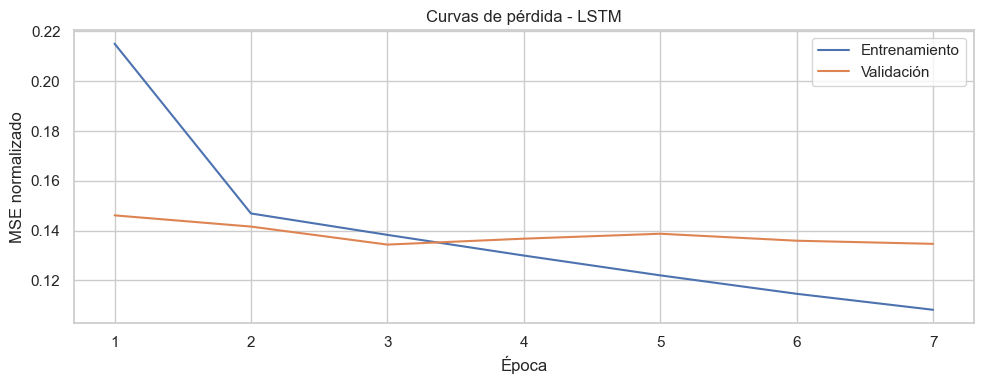

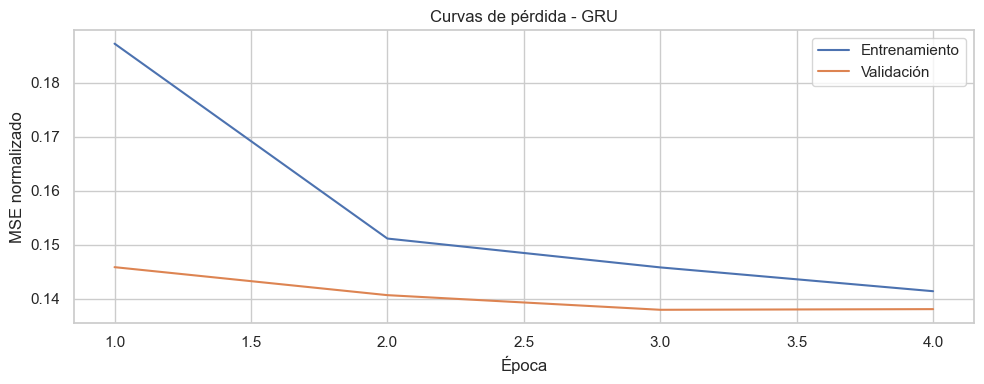

In [39]:
# Se define una función para graficar historias de entrenamiento de Keras.
def graficar_historia(history, titulo):
    # Se convierte el historial a DataFrame para facilitar graficación.
    hist = pd.DataFrame(history.history)

    # Se crea una figura individual.
    plt.figure(figsize=(10, 4))

    # Se grafica la pérdida de entrenamiento.
    plt.plot(hist.index + 1, hist["loss"], label="Entrenamiento")

    # Se grafica la pérdida de validación.
    plt.plot(hist.index + 1, hist["val_loss"], label="Validación")

    # Se etiqueta el eje horizontal como épocas.
    plt.xlabel("Época")

    # Se etiqueta el eje vertical como MSE normalizado.
    plt.ylabel("MSE normalizado")

    # Se asigna título descriptivo.
    plt.title(titulo)

    # Se muestra leyenda.
    plt.legend()

    # Se ajusta el diseño.
    plt.tight_layout()

    # Se muestra la figura.
    plt.show()


# Se grafica la curva de aprendizaje de LSTM.
graficar_historia(history_lstm, "Curvas de pérdida - LSTM")

# Se grafica la curva de aprendizaje de GRU.
graficar_historia(history_gru, "Curvas de pérdida - GRU")

#### Discusión técnica de curvas de aprendizaje

Las curvas permiten diagnosticar convergencia y sobreajuste. Si entrenamiento y validación bajan juntas, el modelo generaliza razonablemente. Si la validación se separa hacia arriba, las capas recurrentes están memorizando patrones del periodo de entrenamiento. La GRU puede necesitar menos tiempo para estabilizarse por tener menos parámetros, mientras que la LSTM puede requerir más épocas para aprovechar su memoria de celda.

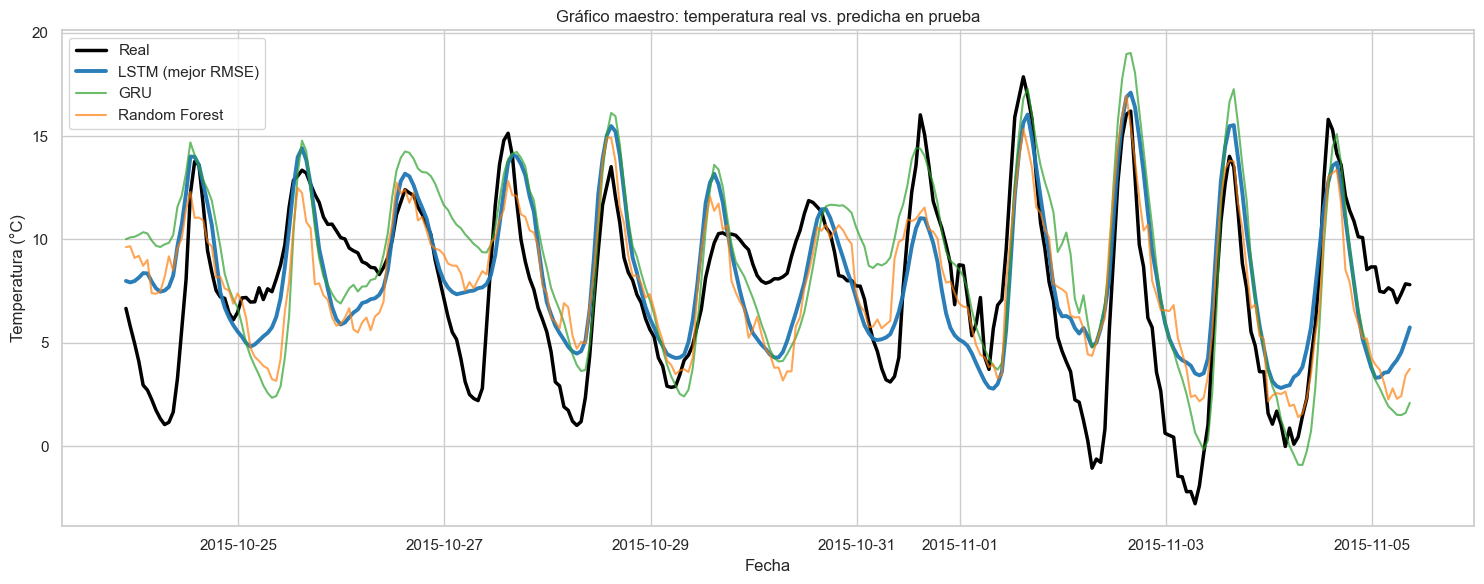

In [40]:
# Se desnormalizan los valores reales de prueba.
y_test_c = desnormalizar_temperatura(y_test)

# Se desnormalizan las predicciones LSTM.
lstm_pred_c = desnormalizar_temperatura(lstm_test_pred)

# Se desnormalizan las predicciones GRU.
gru_pred_c = desnormalizar_temperatura(gru_test_pred)

# Se desnormalizan las predicciones Random Forest.
rf_pred_c = desnormalizar_temperatura(rf_test_pred)

# Se limita el tramo visual a 300 horas para mantener legibilidad.
n_plot = min(300, len(y_test_c))

# Se seleccionan las fechas correspondientes al tramo graficado.
fechas_plot = fechas_test[:n_plot]

# Se asocian predicciones por nombre de modelo.
predicciones = {
    "LSTM": lstm_pred_c,
    "GRU": gru_pred_c,
    "Random Forest": rf_pred_c,
}

# Se define una paleta con contraste para distinguir modelos.
colores = {"LSTM": "#1f77b4", "GRU": "#2ca02c", "Random Forest": "#ff7f0e"}

# Se crea la figura maestra.
plt.figure(figsize=(15, 6))

# Se grafica la serie real con línea negra gruesa.
plt.plot(fechas_plot, y_test_c[:n_plot], label="Real", color="black", linewidth=2.5)

# Se recorre cada modelo para superponer sus predicciones.
for nombre, pred in predicciones.items():
    # Se define mayor grosor si el modelo es el mejor según RMSE.
    ancho = 2.8 if nombre == mejor_modelo else 1.5

    # Se define mayor opacidad si el modelo es el mejor según RMSE.
    alpha = 0.95 if nombre == mejor_modelo else 0.70

    # Se añade texto de etiqueta para resaltar visualmente el mejor modelo.
    etiqueta = f"{nombre} (mejor RMSE)" if nombre == mejor_modelo else nombre

    # Se grafica la predicción del modelo.
    plt.plot(fechas_plot, pred[:n_plot], label=etiqueta, color=colores[nombre], linewidth=ancho, alpha=alpha)

# Se asigna título al gráfico maestro.
plt.title("Gráfico maestro: temperatura real vs. predicha en prueba")

# Se etiqueta el eje horizontal.
plt.xlabel("Fecha")

# Se etiqueta el eje vertical en grados Celsius.
plt.ylabel("Temperatura (°C)")

# Se muestra leyenda.
plt.legend()

# Se ajusta el diseño.
plt.tight_layout()

# Se muestra la figura.
plt.show()

#### Discusión técnica del gráfico maestro

El gráfico maestro permite evaluar forma temporal además de error promedio. Un modelo útil debe seguir ciclos diarios, cambios de nivel y transiciones meteorológicas sin retrasos excesivos. Si una curva predicha es muy suave, probablemente captura la tendencia pero no extremos. La línea resaltada corresponde al mejor RMSE; si esa línea también sigue visualmente los picos y valles, la métrica y el diagnóstico visual son consistentes.

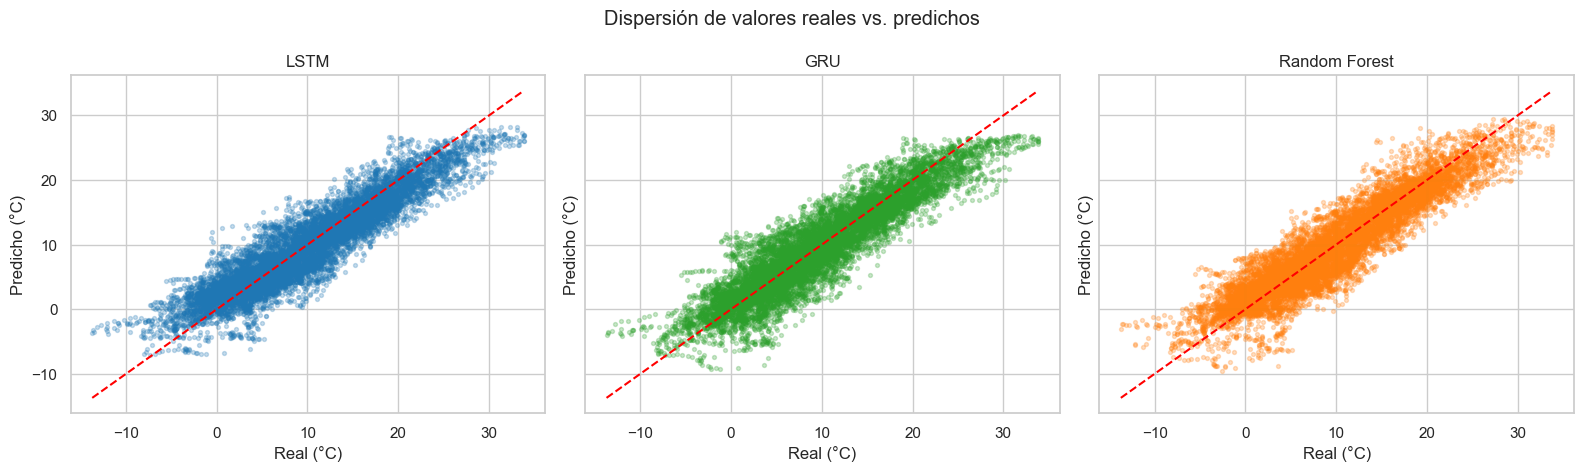

In [41]:
# Se crea una figura con diagramas de dispersión para comparar sesgo.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True, sharey=True)

# Se calcula temperatura mínima global entre reales y predicciones.
temp_min = min(y_test_c.min(), lstm_pred_c.min(), gru_pred_c.min(), rf_pred_c.min())

# Se calcula temperatura máxima global entre reales y predicciones.
temp_max = max(y_test_c.max(), lstm_pred_c.max(), gru_pred_c.max(), rf_pred_c.max())

# Se recorre cada eje y cada modelo.
for ax, (nombre, pred) in zip(axes, predicciones.items()):
    # Se dibuja nube de puntos real vs predicho.
    ax.scatter(y_test_c, pred, s=8, alpha=0.25, color=colores[nombre])

    # Se dibuja línea diagonal de predicción perfecta.
    ax.plot([temp_min, temp_max], [temp_min, temp_max], color="red", linestyle="--")

    # Se asigna título del modelo.
    ax.set_title(nombre)

    # Se etiqueta eje x.
    ax.set_xlabel("Real (°C)")

    # Se etiqueta eje y.
    ax.set_ylabel("Predicho (°C)")

# Se asigna título general.
plt.suptitle("Dispersión de valores reales vs. predichos")

# Se ajusta el diseño.
plt.tight_layout()

# Se muestra la figura.
plt.show()

#### Discusión técnica de dispersión

La diagonal roja representa predicción perfecta. Puntos concentrados alrededor de la diagonal indican bajo sesgo y baja varianza del error. Si los puntos se abren en temperaturas extremas, el modelo es sensible al ruido o tiene dificultades con eventos menos frecuentes. Una nube sistemáticamente por encima o debajo de la diagonal revela sobreestimación o subestimación.

### Cumplimiento: Parte 5 del Taller

Para poder visualizar los **mejores agentes de cada modelo**, se considera cada arquitectura entrenada como un agente predictivo: agente LSTM, agente GRU y agente Random Forest. Como en este experimento hay un entrenamiento por arquitectura, el criterio de selección se aplica sobre sus mejores predicciones individuales en el conjunto de prueba.

La metodología es:

1. Calcular el error absoluto por fecha para cada modelo.
2. Ordenar las predicciones de cada agente por menor error.
3. Mostrar una tabla con los mejores casos de cada agente.
4. Graficar valores reales vs. predichos en esos mejores casos.

Si más adelante se entrenan múltiples corridas por arquitectura, por ejemplo varias LSTM con hiperparámetros distintos, esta misma estructura puede ampliarse agregando una columna `agente_id`.

In [ ]:
# Se define cuántos mejores casos se visualizarán por cada agente/modelo.
TOP_N_AGENTES = 12

# Se crea un diccionario con las predicciones desnormalizadas por modelo.
predicciones_por_modelo = {
    "LSTM": lstm_pred_c,
    "GRU": gru_pred_c,
    "Random Forest": rf_pred_c,
}

# Se crea una lista para almacenar los errores detallados de cada modelo.
filas_error = []

# Se recorre cada agente/modelo y su vector de predicciones.
for nombre_modelo, predicciones_modelo in predicciones_por_modelo.items():
    # Se calcula el error absoluto punto a punto en grados Celsius.
    error_absoluto = np.abs(y_test_c - predicciones_modelo)

    # Se crea un DataFrame con fecha, valor real, predicción y error del modelo actual.
    df_error_modelo = pd.DataFrame({
        "modelo": nombre_modelo,
        "fecha": fechas_test,
        "real_°C": y_test_c,
        "predicho_°C": predicciones_modelo,
        "error_abs_°C": error_absoluto,
    })

    # Se agrega el RMSE global del modelo para conectar caso local con desempeño general.
    df_error_modelo["rmse_global_°C"] = metricas.loc[
        metricas["Modelo"] == nombre_modelo, "RMSE (°C)"
    ].iloc[0]

    # Se almacena el DataFrame del modelo actual.
    filas_error.append(df_error_modelo)

# Se concatena el detalle de errores de todos los modelos.
errores_detallados = pd.concat(filas_error, ignore_index=True)

# Se ordena por modelo y error absoluto para identificar las mejores predicciones de cada agente.
mejores_agentes = (
    errores_detallados
    .sort_values(["modelo", "error_abs_°C"])
    .groupby("modelo", group_keys=False)
    .head(TOP_N_AGENTES)
    .copy()
)

# Se asigna un ranking interno dentro de cada agente/modelo.
mejores_agentes["ranking_agente"] = mejores_agentes.groupby("modelo")["error_abs_°C"].rank(method="first")

# Se reordena la tabla para lectura.
mejores_agentes = mejores_agentes[
    ["modelo", "ranking_agente", "fecha", "real_°C", "predicho_°C", "error_abs_°C", "rmse_global_°C"]
].sort_values(["modelo", "ranking_agente"])

# Se muestra la tabla de mejores agentes/casos por modelo.
display(mejores_agentes.style.format({
    "ranking_agente": "{:.0f}",
    "real_°C": "{:.3f}",
    "predicho_°C": "{:.3f}",
    "error_abs_°C": "{:.4f}",
    "rmse_global_°C": "{:.4f}",
}))

#### Discusión técnica de los mejores agentes

La tabla muestra los instantes donde cada agente predictivo tuvo menor error absoluto. Estos casos son útiles para entender cuándo el modelo funciona especialmente bien: normalmente corresponden a periodos donde la temperatura evoluciona de forma suave o donde el patrón reciente de la ventana es altamente informativo.

Es importante no confundir esta tabla con el ranking global. Un modelo puede tener algunos casos casi perfectos y aun así generalizar peor si falla en muchos otros puntos. Por eso se incluye `rmse_global_°C`, que resume el desempeño completo del conjunto de prueba.

In [ ]:
# Se define el orden visual de los modelos para mantener consistencia con gráficas anteriores.
orden_modelos = ["LSTM", "GRU", "Random Forest"]

# Se crea una figura con un panel por agente/modelo.
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)

# Se recorre cada eje junto con su modelo correspondiente.
for ax, nombre_modelo in zip(axes, orden_modelos):
    # Se filtran los mejores casos del modelo actual.
    datos_modelo = mejores_agentes[mejores_agentes["modelo"] == nombre_modelo].copy()

    # Se ordenan por ranking para mostrar primero los casos con menor error.
    datos_modelo = datos_modelo.sort_values("ranking_agente")

    # Se crea un eje x discreto para los mejores casos.
    x = np.arange(len(datos_modelo))

    # Se dibujan líneas verticales entre real y predicho para visualizar el error.
    ax.vlines(
        x,
        datos_modelo["real_°C"],
        datos_modelo["predicho_°C"],
        color="gray",
        alpha=0.45,
        linewidth=1.2,
    )

    # Se dibujan los valores reales como puntos negros.
    ax.scatter(x, datos_modelo["real_°C"], color="black", label="Real", s=45, zorder=3)

    # Se dibujan los valores predichos con el color del modelo.
    ax.scatter(
        x,
        datos_modelo["predicho_°C"],
        color=colores[nombre_modelo],
        label="Predicho",
        s=45,
        zorder=3,
    )

    # Se marca el panel del mejor modelo global con un título explícito.
    sufijo = " | Mejor global" if nombre_modelo == mejor_modelo else ""

    # Se asigna título al panel.
    ax.set_title(f"{nombre_modelo}{sufijo}")

    # Se etiqueta el eje x como ranking de mejores casos.
    ax.set_xlabel("Ranking interno del agente")

    # Se etiqueta el eje y en grados Celsius.
    ax.set_ylabel("Temperatura (°C)")

    # Se fija el tick de cada caso mostrado.
    ax.set_xticks(x)

    # Se rotulan los ticks desde 1 hasta TOP_N_AGENTES.
    ax.set_xticklabels(datos_modelo["ranking_agente"].astype(int))

    # Se activa una cuadrícula ligera para facilitar lectura.
    ax.grid(True, alpha=0.25)

# Se toma la leyenda del primer eje para evitar duplicación excesiva.
handles, labels = axes[0].get_legend_handles_labels()

# Se crea una leyenda general para toda la figura.
fig.legend(handles, labels, loc="upper center", ncol=2)

# Se agrega título general a la visualización.
fig.suptitle("Mejores predicciones por agente/modelo en el conjunto de prueba", y=1.05)

# Se ajusta el diseño para evitar superposición.
plt.tight_layout()

# Se muestra la figura.
plt.show()

#### Discusión técnica de la visualización de agentes

Cada panel compara los mejores casos del agente correspondiente. La distancia vertical entre el punto negro y el punto de color representa el error absoluto. Cuando ambos puntos casi se superponen, el agente predijo muy cerca del valor real.

Esta visualización ayuda a distinguir desempeño local y desempeño global. El mejor agente global se define por RMSE en toda la prueba, pero los mejores casos locales muestran bajo qué condiciones cada modelo logra predicciones prácticamente exactas. Si un modelo aparece muy preciso en sus mejores casos pero tiene peor RMSE global, probablemente es más sensible al ruido o a cambios bruscos.

### Cumplimiento: Parte 5 del Taller

Esta sección final entrega conclusiones argumentadas sobre generalización, longitud de secuencia y ventajas de GRU frente a LSTM. Las conclusiones deben leerse junto con la tabla de métricas y las gráficas generadas al ejecutar el notebook.

In [42]:
# Se muestra nuevamente el ranking final para apoyar las conclusiones.
display(metricas)

# Se imprime una conclusión cuantitativa automática según RMSE.
print(f"Modelo con mejor generalización según RMSE: {mejor_modelo}")

# Se compara número de parámetros recurrentes entre LSTM y GRU.
print("Parámetros LSTM:", lstm_model.count_params())

# Se compara número de parámetros recurrentes entre LSTM y GRU.
print("Parámetros GRU:", gru_model.count_params())

,Modelo,MAE (°C),MSE,RMSE (°C),R2,MAPE (%)
0,LSTM,2.379768,9.073333,3.012197,0.851786,135.268456
1,Random Forest,2.366727,9.102343,3.017009,0.851312,130.940740
2,GRU,2.465992,10.002390,3.162655,0.836610,163.632141


Modelo con mejor generalización según RMSE: LSTM
Parámetros LSTM: 33185
Parámetros GRU: 25025


#### Conclusiones argumentadas

**¿Qué modelo generaliza mejor?**  
El modelo que generaliza mejor es el que obtiene menor RMSE y MAE en prueba. Si la red recurrente ganadora supera a Random Forest, se concluye que la estructura secuencial aporta información adicional frente a los rezagos aplanados. Si Random Forest gana, significa que para este horizonte las relaciones no lineales tabulares fueron suficientes o que las redes requieren ajuste adicional.

**¿Cómo afectó la longitud de la secuencia?**  
La ventana de 120 horas incluye cinco ciclos diarios, lo que es adecuado para temperatura porque captura patrones día/noche y cambios meteorológicos de varios días. Una ventana menor, por ejemplo 24 horas, reduciría costo pero podría perder contexto. Una ventana mayor, por ejemplo 168 horas, podría capturar ciclos semanales, aunque aumentaría parámetros efectivos, memoria y riesgo de sobreajuste.

**¿Qué ventajas ofreció la GRU sobre la LSTM en tiempo y precisión?**  
La GRU tiene menos parámetros porque reemplaza la estructura de memoria más compleja de la LSTM por dos compuertas explícitas y un candidato de estado. Esto suele reducir tiempo de entrenamiento y uso de memoria. Si su precisión es similar a la LSTM, la GRU es preferible por eficiencia. Si la LSTM obtiene una mejora clara, su estado de celda separado justificó el mayor costo computacional.

**Sobreajuste y sensibilidad al ruido.**  
La diferencia entre pérdida de entrenamiento y validación indica sobreajuste. El clipping de atípicos reduce sensibilidad a ruido meteorológico extremo, y Dropout/EarlyStopping ayudan a evitar memorización. Random Forest puede ser robusto ante ruido puntual por promediar árboles, pero puede perder continuidad temporal al trabajar con ventanas aplanadas.